In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../dataset/processed/cleaned_house_prices.csv')
df.head()

,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,LOCALITY,FORMATTED_ADDRESS
0,House for sale,94601238.0,5,5,5938.49,"Moratuwa, Colombo",Moratuwa,"Moratuwa, Colombo"
1,House for sale,46044725.0,3,3,1768.45,"Homagama, Colombo",Homagama,"Homagama, Colombo"
2,House for sale,90985626.0,5,4,5063.38,"Boralesgamuwa, Colombo",Boralesgamuwa,"Boralesgamuwa, Colombo"
3,House for sale,28967644.0,3,2,2619.82,"Piliyandala, Colombo",Piliyandala,"Piliyandala, Colombo"
4,Villa for sale,98596073.0,5,5,4914.25,"Boralesgamuwa, Colombo",Boralesgamuwa,"Boralesgamuwa, Colombo"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TYPE               2997 non-null   object 
 1   PRICE              2997 non-null   float64
 2   BEDS               2997 non-null   int64  
 3   BATH               2997 non-null   int64  
 4   PROPERTYSQFT       2997 non-null   float64
 5   ADDRESS            2997 non-null   object 
 6   LOCALITY           2997 non-null   object 
 7   FORMATTED_ADDRESS  2997 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 187.4+ KB


In [5]:
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT
count,2.997000e+03,2997.000000,2997.000000,2997.000000
mean,8.620929e+07,4.244912,3.621622,3307.545506
std,8.551143e+07,1.663661,1.400567,1828.523152
min,5.500000e+06,1.000000,1.000000,500.000000
25%,3.323737e+07,3.000000,3.000000,1974.950000
50%,5.821799e+07,4.000000,3.000000,3083.410000
75%,1.078407e+08,5.000000,4.000000,4139.820000
max,8.500000e+08,10.000000,10.000000,15000.000000


In [6]:
df["PRICE"].describe()

count    2.997000e+03
mean     8.620929e+07
std      8.551143e+07
min      5.500000e+06
25%      3.323737e+07
50%      5.821799e+07
75%      1.078407e+08
max      8.500000e+08
Name: PRICE, dtype: float64

In [8]:
print(f"Mean Price: {df['PRICE'].mean():.2f}")
print(f"Standard Deviation: {df['PRICE'].std():.2f}")
print(f"Minimum Price: {df['PRICE'].min():.2f}")
print(f"Maximum Price: {df['PRICE'].max():.2f}")
print(f"Median Price: {df['PRICE'].median():.2f}")

Mean Price: 86209285.43
Standard Deviation: 85511425.87
Minimum Price: 5500000.00
Maximum Price: 850000000.00
Median Price: 58217994.00


## Price destribution

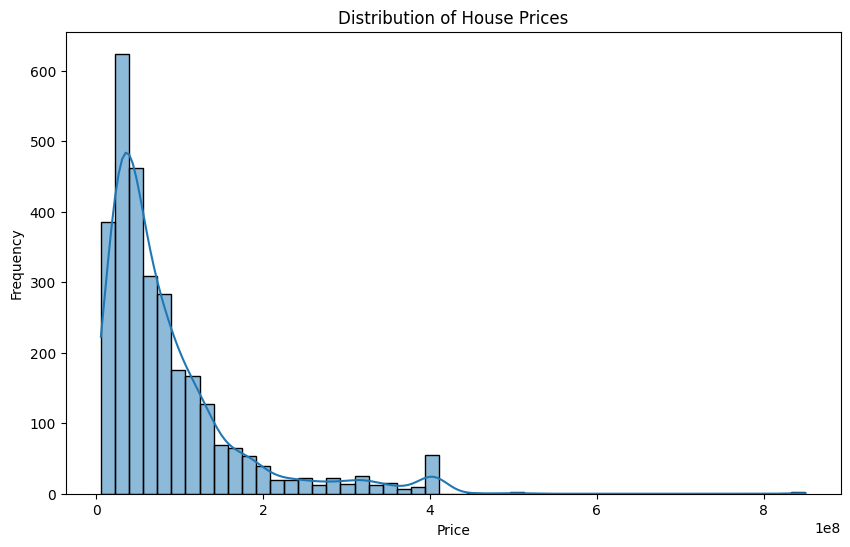

In [10]:
# Hostogram

plt.figure(figsize=(10, 6))
sns.histplot(df['PRICE'], bins=50, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## Boxplot for price

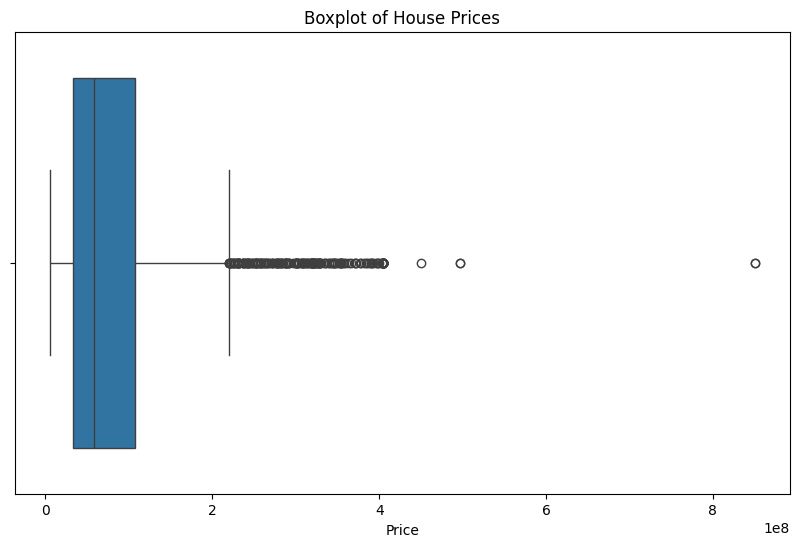

In [11]:
# Boxplot for price distribution

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['PRICE'])

plt.title('Boxplot of House Prices')
plt.xlabel('Price')
plt.show()

## Bed rooms vs price

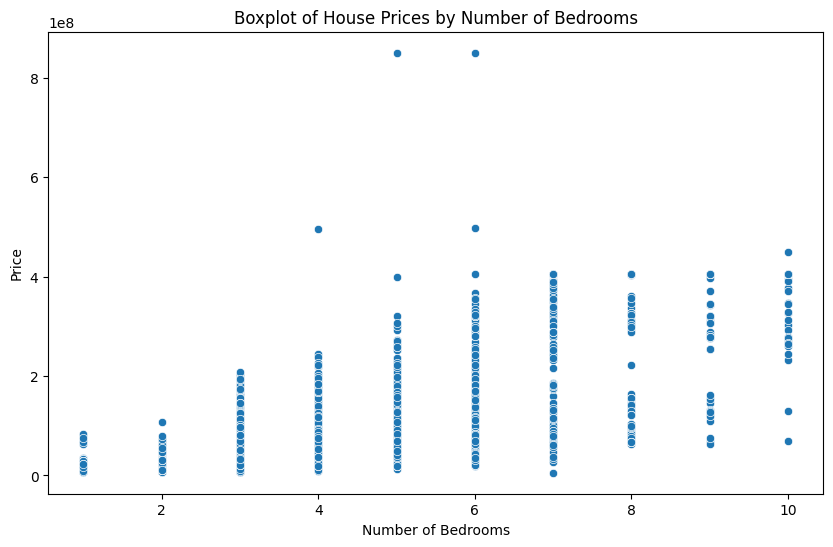

In [14]:
# bed rooms vs price

plt.figure(figsize=(10, 6))
sns.scatterplot(x='BEDS', y='PRICE', data=df)

plt.title('Boxplot of House Prices by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

In [15]:
df.groupby("BEDS")["PRICE"].mean().sort_index()

BEDS
1     2.311287e+07
2     2.594039e+07
3     5.363825e+07
4     7.155976e+07
5     9.192428e+07
6     1.377695e+08
7     2.079189e+08
8     2.061697e+08
9     2.873831e+08
10    3.383448e+08
Name: PRICE, dtype: float64

## Bathrooms vs Price

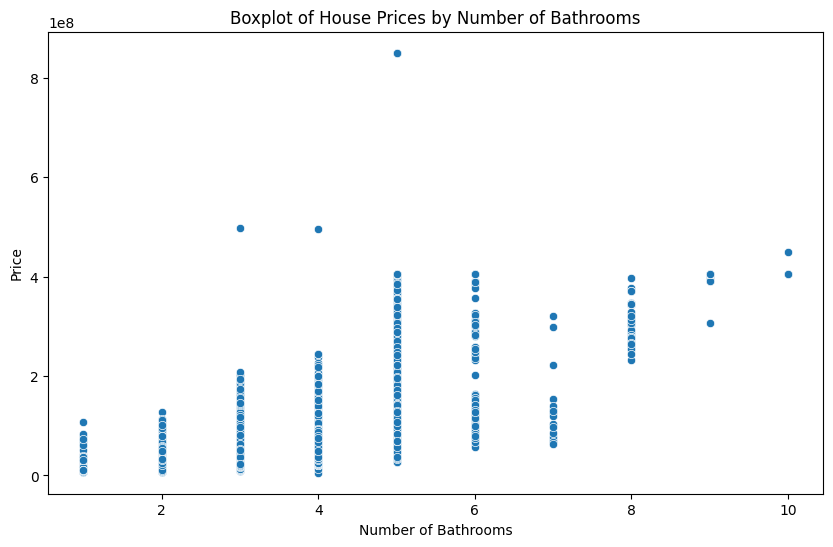

In [16]:
# bathrooms vs price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BATH', y='PRICE', data=df)

plt.title('Boxplot of House Prices by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.show()

## Property size vs price

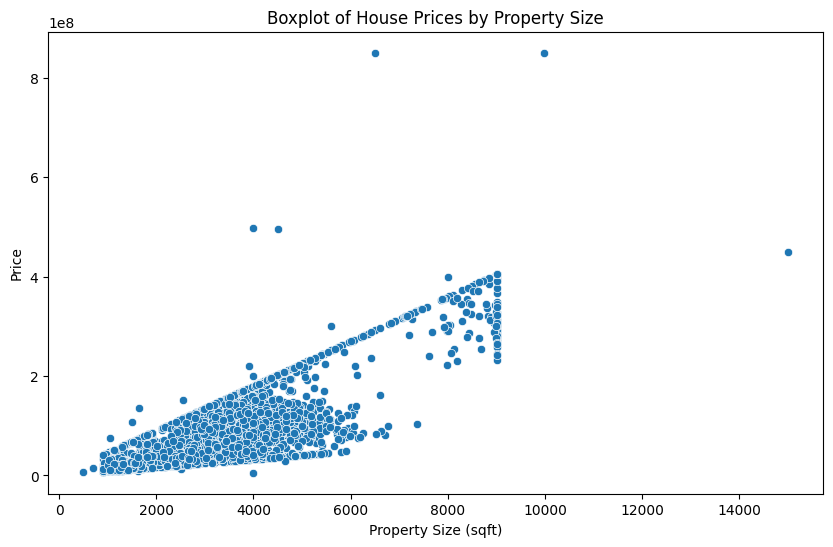

In [17]:
# Property size vs price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PROPERTYSQFT', y='PRICE', data=df)

plt.title('Boxplot of House Prices by Property Size')
plt.xlabel('Property Size (sqft)')
plt.ylabel('Price')
plt.show()

## Property type analysis

In [19]:
df['TYPE'].value_counts()

TYPE
House for sale    2826
Villa for sale     171
Name: count, dtype: int64

In [21]:
type_prices = (
    df.groupby('TYPE')['PRICE']
    .agg(['mean', 'median','count'])
    .sort_values(by='mean', ascending=False)
)

print(type_prices)

                        mean      median  count
TYPE                                           
House for sale  8.659959e+07  57303364.5   2826
Villa for sale  7.975902e+07  73136960.0    171


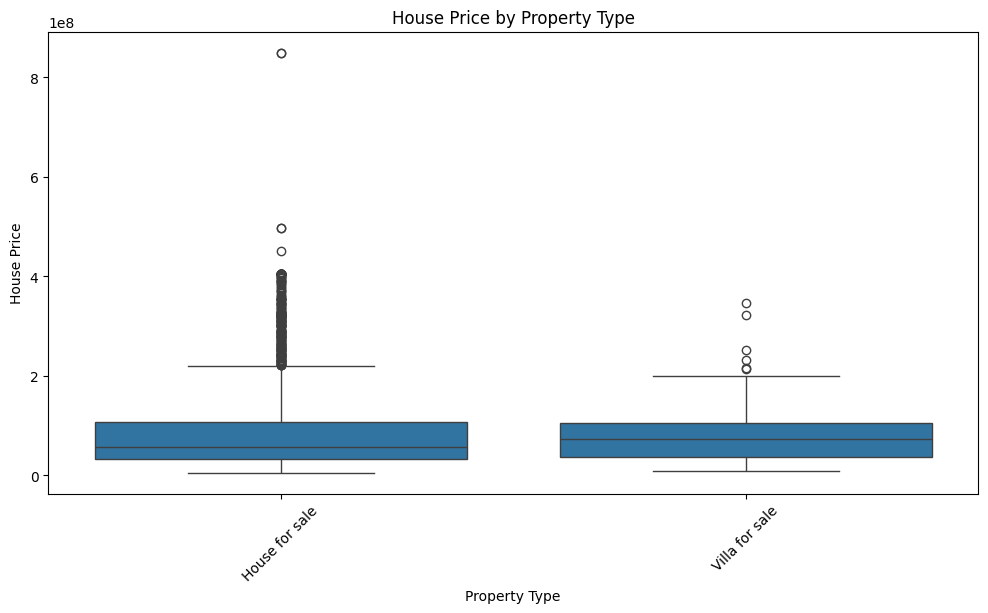

In [22]:
top_types = df["TYPE"].value_counts().head(10).index

type_data = df[
    df["TYPE"].isin(top_types)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=type_data,
    x="TYPE",
    y="PRICE"
)

plt.xticks(rotation=45)

plt.xlabel("Property Type")
plt.ylabel("House Price")
plt.title("House Price by Property Type")

plt.show()